<a href="https://colab.research.google.com/github/UKD1211/Tier_N_Supplier_Visibility_Risk_Pred/blob/main/supplier_risk_pred_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np


In [64]:
df_main= pd.read_csv("/content/final_dataset_main.csv")

In [65]:
# df_main.drop(columns = ['Unnamed: 0'], inplace = True)

In [66]:
df_main

,supplier_id,tier,state,cluster,stage,state_risk_cal,SDG_2023_24,labour_intensity,informality,visibility,cost_pressure,risk_score,high_risk
0,T1_000,1,Andhra Pradesh,Cotton Belt,Raw,0.633688,74,0.2324,0.3917,0.9305,0.3066,0.3084,0
1,T1_001,1,Karnataka,Mysore Silk,Raw,0.560140,75,0.2790,0.3184,0.9153,0.2723,0.2847,0
2,T1_002,1,Telangana,Cotton Belt,Raw,0.585616,74,0.1768,0.3193,0.8907,0.3214,0.2718,0
3,T1_003,1,Karnataka,Mysore Silk,Raw,0.560140,75,0.1138,0.3422,0.8888,0.1884,0.2330,0
4,T1_004,1,Karnataka,Mysore Silk,Raw,0.560140,75,0.1546,0.2794,0.8718,0.2998,0.2463,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,T4_025,4,Karnataka,Bangalore,Garment,0.560137,75,0.9150,0.7783,0.1043,0.7058,0.8654,1
116,T4_026,4,Tamil Nadu,Tiruppur,Garment,0.501682,78,0.9807,0.6452,0.1152,0.6696,0.8157,1
117,T4_027,4,Uttar Pradesh,Noida,Garment,0.917599,67,0.9362,0.8323,0.0540,0.8182,0.9347,1
118,T4_028,4,Tamil Nadu,Tiruppur,Garment,0.501682,78,1.0000,0.5751,0.0950,0.7490,0.8130,1


In [67]:
df_main['high_risk'].value_counts(normalize = True)*100

,proportion
high_risk,
0,72.5
1,27.5


In [68]:
df_main.drop(columns = ['supplier_id', 'state', 'cluster', 'risk_score', 'stage'], inplace = True)

In [69]:
df_main

,tier,state_risk_cal,SDG_2023_24,labour_intensity,informality,visibility,cost_pressure,high_risk
0,1,0.633688,74,0.2324,0.3917,0.9305,0.3066,0
1,1,0.560140,75,0.2790,0.3184,0.9153,0.2723,0
2,1,0.585616,74,0.1768,0.3193,0.8907,0.3214,0
3,1,0.560140,75,0.1138,0.3422,0.8888,0.1884,0
4,1,0.560140,75,0.1546,0.2794,0.8718,0.2998,0
...,...,...,...,...,...,...,...,...
115,4,0.560137,75,0.9150,0.7783,0.1043,0.7058,1
116,4,0.501682,78,0.9807,0.6452,0.1152,0.6696,1
117,4,0.917599,67,0.9362,0.8323,0.0540,0.8182,1
118,4,0.501682,78,1.0000,0.5751,0.0950,0.7490,1


In [70]:
X = df_main.drop(columns = ['high_risk'])
y = df_main['high_risk']

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.35, random_state = 42, stratify = y)

In [73]:
X_train

,tier,state_risk_cal,SDG_2023_24,labour_intensity,informality,visibility,cost_pressure
6,1,0.585616,74,0.1425,0.3156,0.9075,0.2998
33,2,0.608607,73,0.4540,0.4012,0.5310,0.4471
11,1,0.585616,74,0.1770,0.2689,0.9211,0.2583
25,1,0.560140,75,0.1829,0.2593,0.8840,0.2630
114,4,0.501682,78,0.9223,0.6455,0.0760,0.6289
...,...,...,...,...,...,...,...
102,4,0.917600,67,0.9856,0.8648,0.0775,0.8728
34,2,0.693935,74,0.5407,0.4578,0.4754,0.4415
24,1,0.720219,70,0.2003,0.4249,0.8953,0.3611
49,2,0.501682,78,0.5029,0.3566,0.4771,0.3884


In [74]:
y_train.value_counts(normalize = True)*100

,proportion
high_risk,
0,73.076923
1,26.923077


In [75]:
y_test.value_counts(normalize = True)*100

,proportion
high_risk,
0,71.428571
1,28.571429


In [76]:
#EDA #distribution of the risk here

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid", context="talk")

In [78]:
test_df = pd.read_csv("/content/final_dataset_main.csv")

<Axes: xlabel='risk_score', ylabel='Density'>

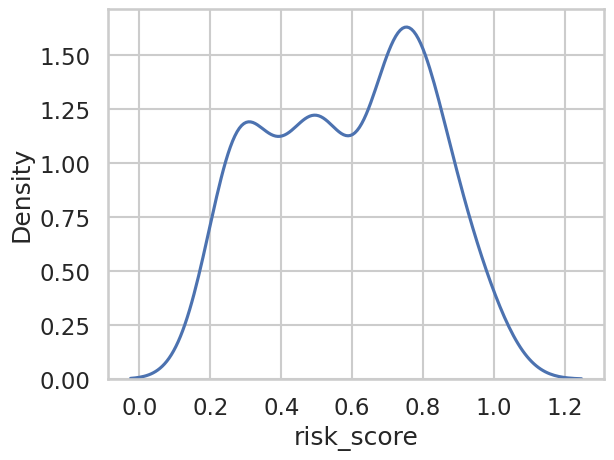

In [79]:
sns.kdeplot(test_df['risk_score'])

<Axes: xlabel='high_risk'>

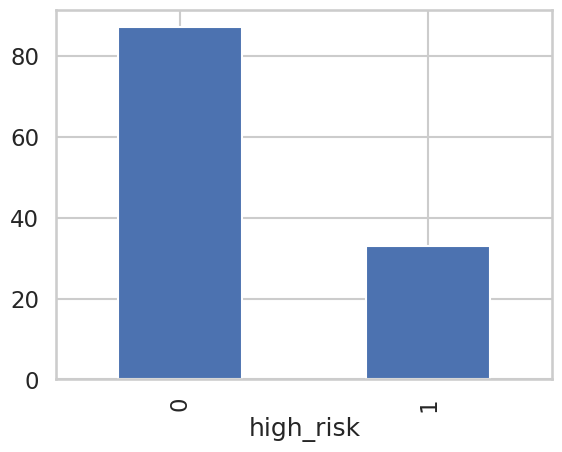

In [80]:
df_main['high_risk'].value_counts().plot(kind = 'bar')

/tmp/ipykernel_914/1520842756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


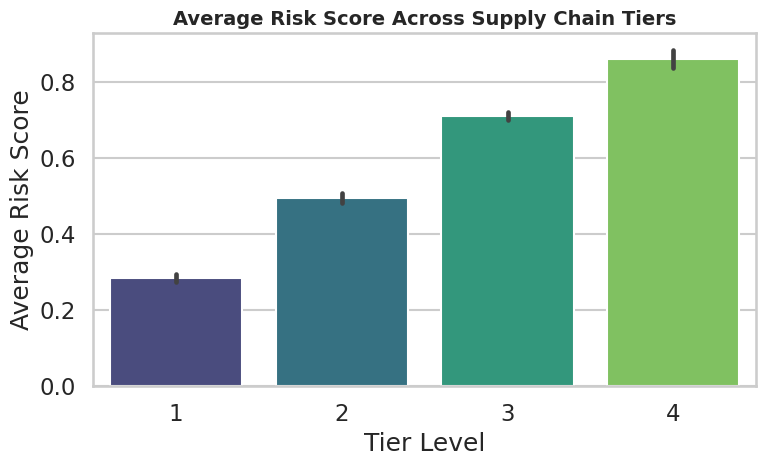

In [81]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='tier',
    y='risk_score',
    data=test_df,
    palette='viridis'   # smooth professional gradient
)

plt.title("Average Risk Score Across Supply Chain Tiers", fontsize=14, weight='bold')
plt.xlabel("Tier Level")
plt.ylabel("Average Risk Score")

plt.tight_layout()
plt.savefig("tier_vs_risk_bar.png", dpi=300)  # save for PPT
plt.show()

/tmp/ipykernel_914/2631422158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


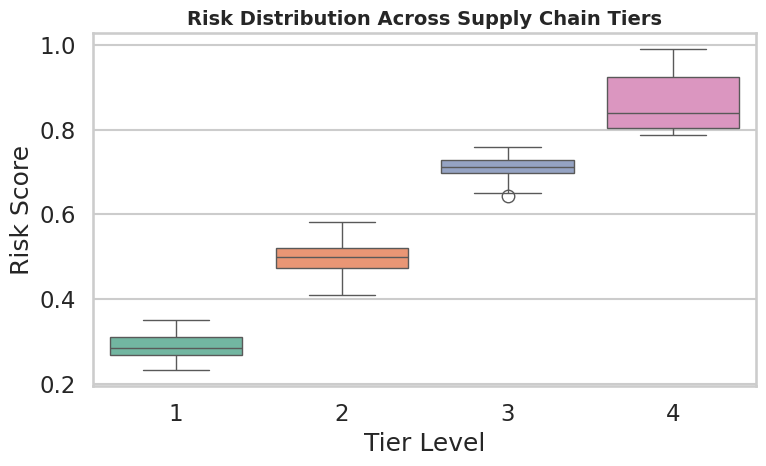

In [82]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='tier',
    y='risk_score',
    data=test_df,
    palette='Set2'   # distinct colors for tiers
)

plt.title("Risk Distribution Across Supply Chain Tiers", fontsize=14, weight='bold')
plt.xlabel("Tier Level")
plt.ylabel("Risk Score")

plt.tight_layout()
plt.savefig("tier_vs_risk_box.png", dpi=300)
plt.show()

In [83]:
pd.crosstab(test_df['tier'], test_df['high_risk'])

high_risk,0,1
tier,,
1,30,0
2,30,0
3,27,3
4,0,30


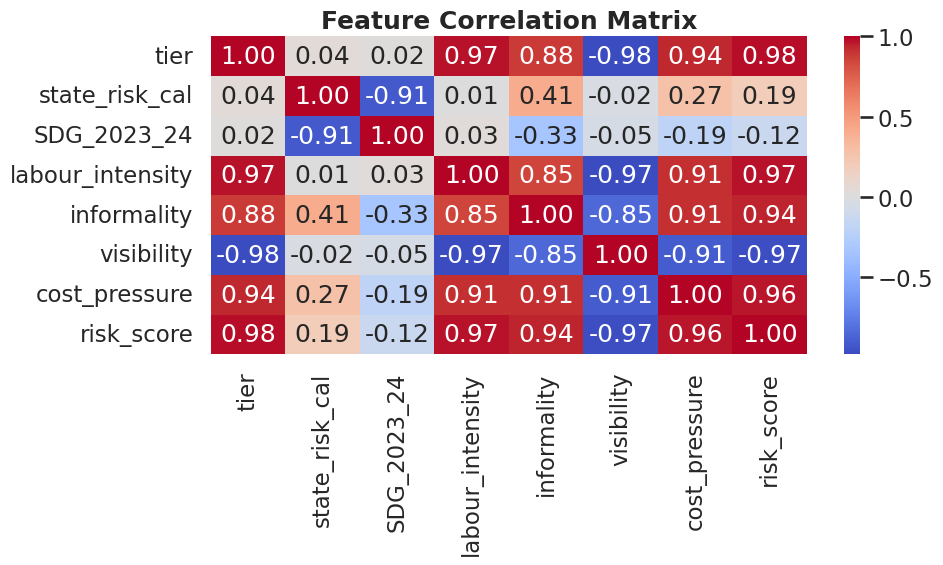

In [84]:
plt.figure(figsize=(10,6))
df_corr = test_df.drop(columns=['supplier_id', 'state', 'cluster', 'stage', 'high_risk'])
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix", weight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

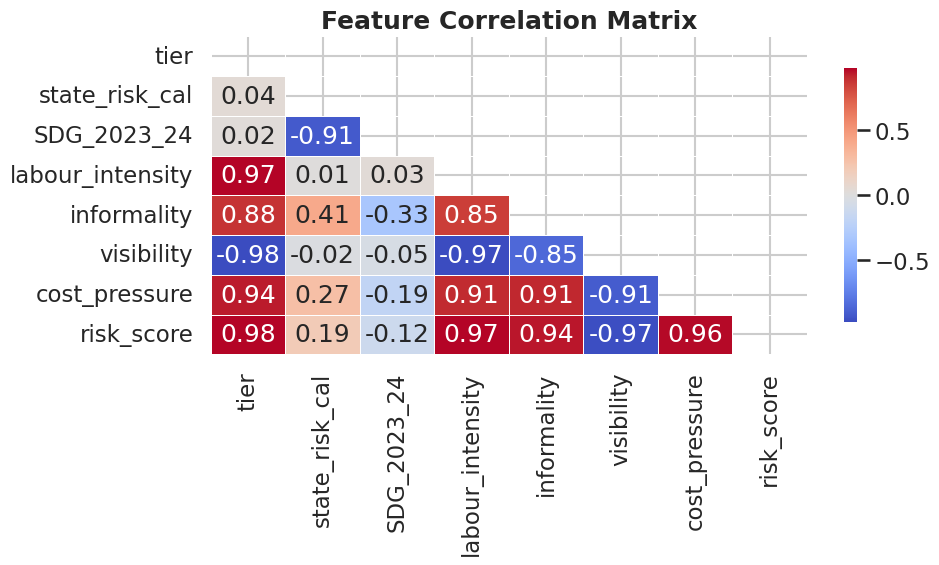

In [85]:
plt.figure(figsize=(10,6))

df_corr = test_df.drop(columns=[
    'supplier_id', 'state', 'cluster', 'stage', 'high_risk'
])

corr = df_corr.corr()

# Create mask for upper triangle (including diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Matrix", weight='bold')
plt.tight_layout()
plt.savefig("correlation_lower_triangle.png", dpi=300)
plt.show()

Axes(0.125,0.11;0.775x0.77)


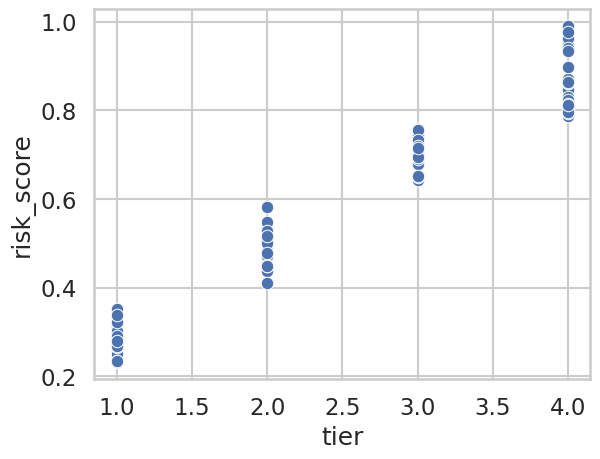

In [86]:
print(sns.scatterplot(data = test_df, y = 'risk_score', x = 'tier'))

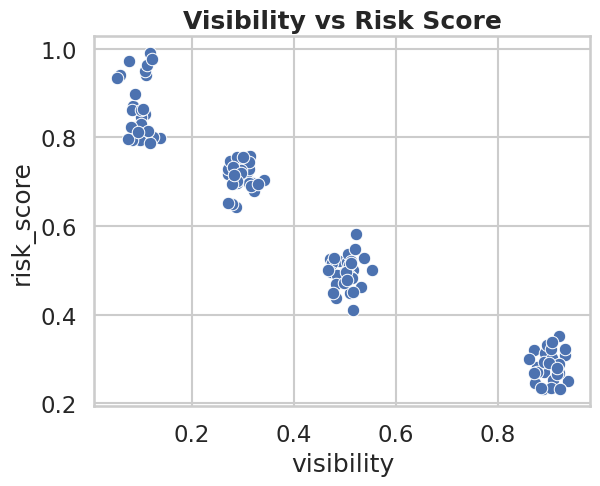

In [87]:
sns.scatterplot(x='visibility', y='risk_score', data=test_df)
plt.title("Visibility vs Risk Score", weight='bold')
plt.show()

/tmp/ipykernel_914/911696505.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_914/911696505.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_914/911696505.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_914/911696505.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_914/911696505.py:18: FutureWarning: 

Passing `pa

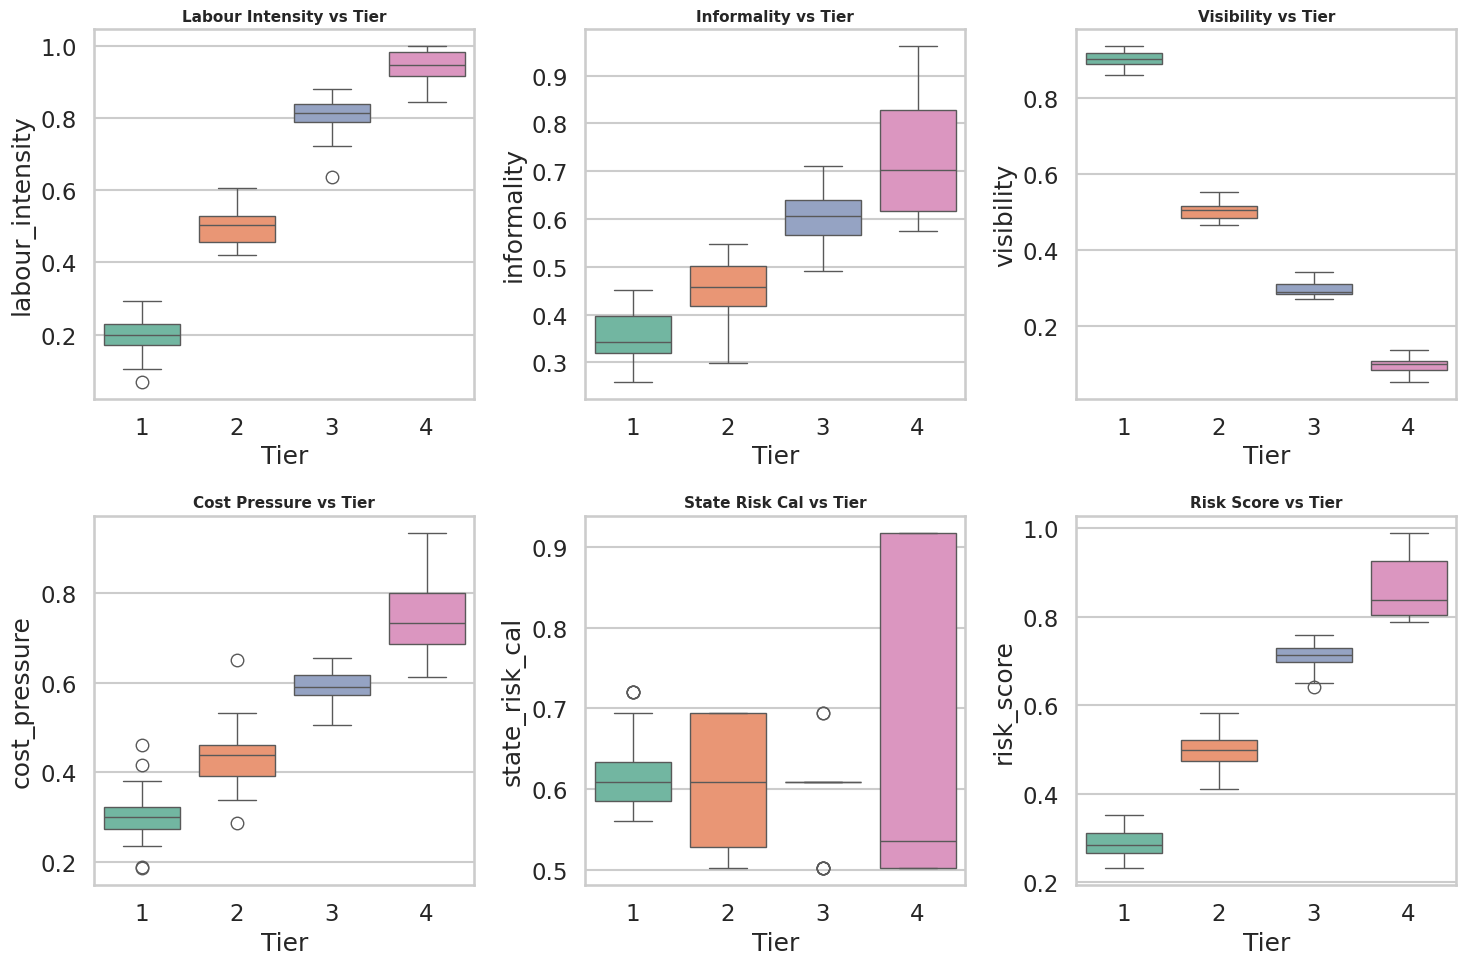

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'labour_intensity',
    'informality',
    'visibility',
    'cost_pressure',
    'state_risk_cal',
    'risk_score'
]

plt.figure(figsize=(15,10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)

    sns.boxplot(
        x='tier',
        y=feature,
        data=test_df,
        palette='Set2'
    )

    plt.title(f"{feature.replace('_',' ').title()} vs Tier", fontsize=11, weight='bold')
    plt.xlabel("Tier")
    plt.ylabel(feature)

plt.tight_layout()
plt.savefig("tier_vs_features_boxplots.png", dpi=300)
plt.show()

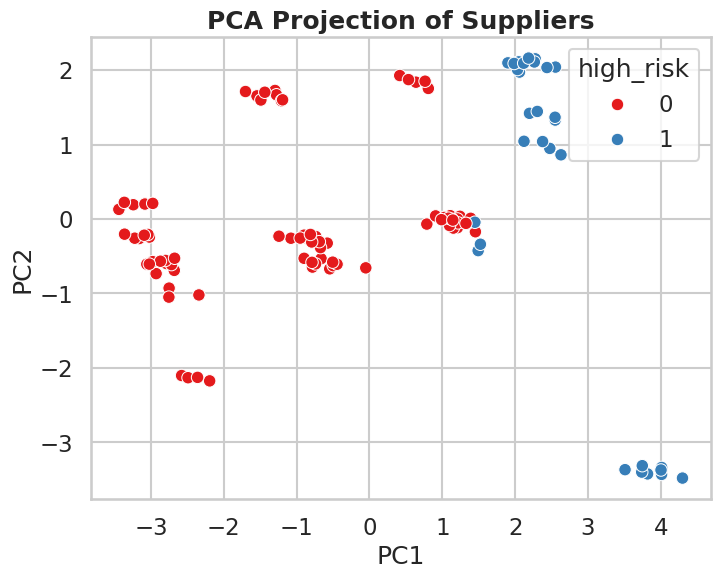

In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# features only - use 'test_df' which is the original dataframe
X_pca_features = test_df.drop(columns=['supplier_id', 'risk_score', 'high_risk',
                                     'state', 'cluster', 'stage'])

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_features)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# create dataframe
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
# Get high_risk from the original test_df
pca_df['high_risk'] = test_df['high_risk']

# plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='high_risk', palette='Set1')
plt.title("PCA Projection of Suppliers", weight='bold')
plt.show()

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,precision_recall_curve,roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [91]:
lor = LogisticRegression(max_iter=1000)
rfc = RandomForestClassifier(n_estimators=100)
dtc = DecisionTreeClassifier()
gbc = GradientBoostingClassifier()

In [92]:
lor.fit(X_train, y_train)
rfc.fit(X_train, y_train)
dtc.fit(X_train, y_train)
gbc.fit(X_train, y_train)

GradientBoostingClassifier()

In [93]:
y_pred_lor = lor.predict(X_test)
y_pred_rfc = rfc.predict(X_test)
y_pred_dtc = dtc.predict(X_test)
y_pred_gbc = gbc.predict(X_test)

In [94]:
rfc.feature_importances_

array([0.25121275, 0.0121529 , 0.00925703, 0.19796505, 0.09095048,
       0.27854374, 0.15991804])

In [95]:
df_main.columns[0:-1].ravel().values

array(['tier', 'state_risk_cal', 'SDG_2023_24', 'labour_intensity',
       'informality', 'visibility', 'cost_pressure'], dtype=object)

In [96]:
importance_df = pd.DataFrame({
    'features': df_main.columns[0:-1].values,
    'importance': rfc.feature_importances_
})

In [97]:
importance_df.sort_values(by = 'importance', ascending = False, inplace = True)

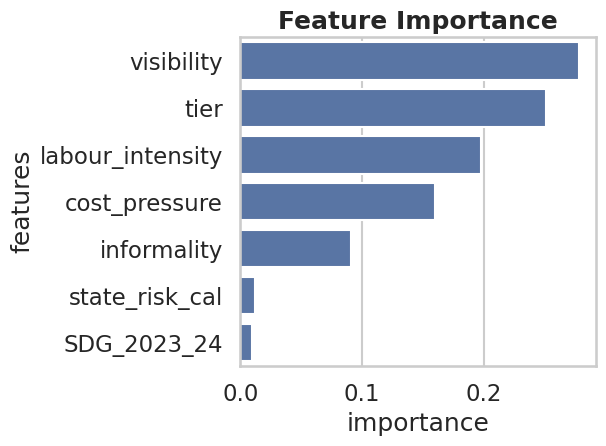

In [98]:
sns.barplot(data = importance_df, x = 'importance', y = 'features')
plt.title("Feature Importance", weight='bold')
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

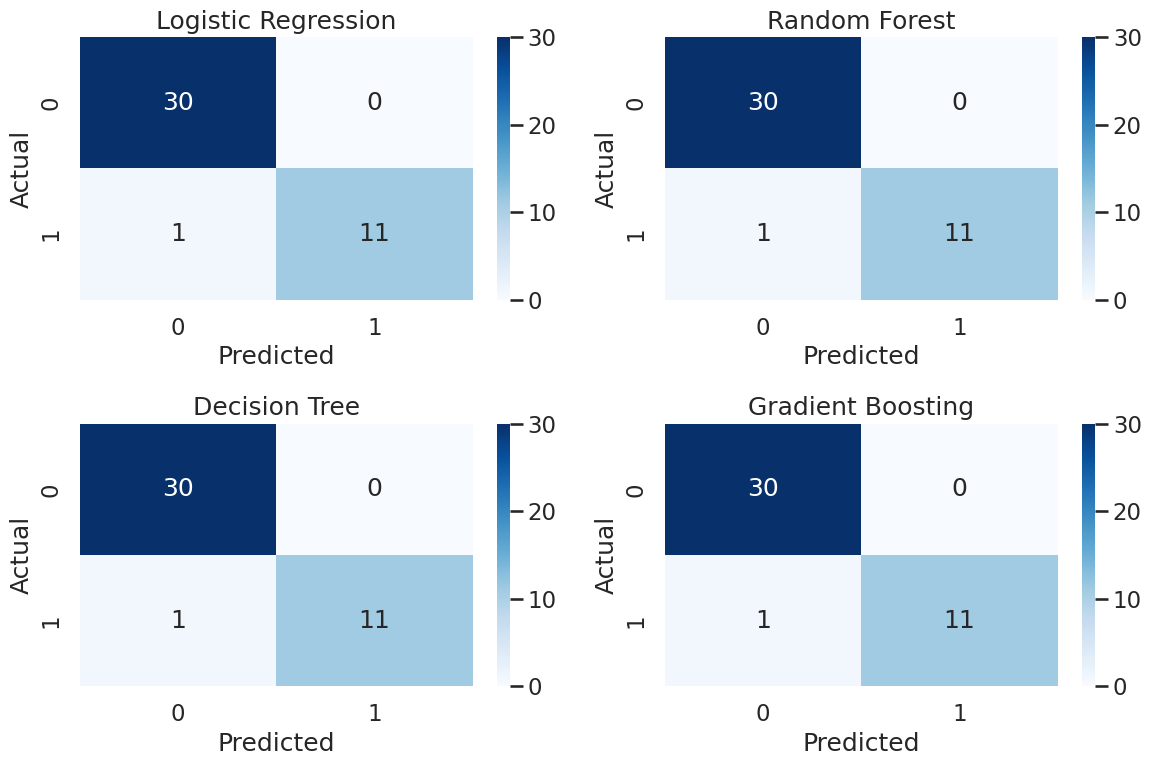

                 Model  Accuracy  Precision (High Risk)  Recall (High Risk)  \
0  Logistic Regression   0.97619                    1.0            0.916667   
1        Random Forest   0.97619                    1.0            0.916667   
2        Decision Tree   0.97619                    1.0            0.916667   
3    Gradient Boosting   0.97619                    1.0            0.916667   

   F1 Score  
0  0.956522  
1  0.956522  
2  0.956522  
3  0.956522  


In [99]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

models = {
    "Logistic Regression": y_pred_lor,
    "Random Forest": y_pred_rfc,
    "Decision Tree": y_pred_dtc,
    "Gradient Boosting": y_pred_gbc
}

# 📊 1. Confusion Matrices
plt.figure(figsize=(12,8))

for i, (name, y_pred) in enumerate(models.items(), 1):
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(2,2,i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("all_confusion_matrices.png", dpi=300)
plt.show()


# 📈 2. Metrics Table (HIGH RISK FOCUS)

results = []

for name, y_pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (High Risk)": precision_score(y_test, y_pred),
        "Recall (High Risk)": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

In [100]:
y_prob = lor.predict_proba(X_test)[:,1]

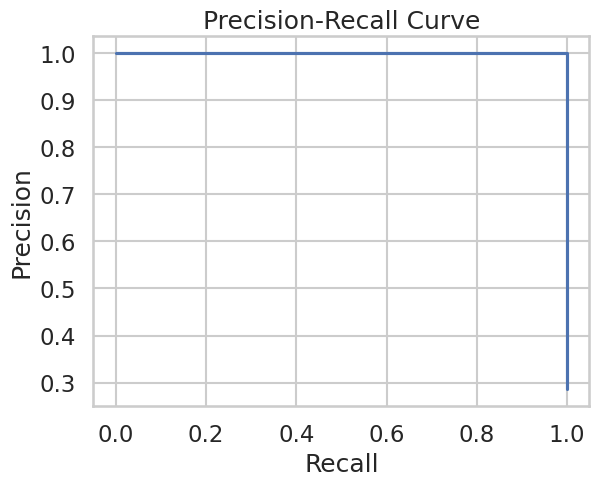

In [101]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [102]:
lor.predict_proba(X_test)[:,1]

array([8.77721435e-01, 1.14506896e-02, 4.92314322e-04, 2.27789015e-01,
       2.30229743e-01, 2.32322798e-01, 1.28935829e-02, 2.30683556e-01,
       8.59594956e-01, 2.27128370e-01, 2.39573118e-01, 2.29446298e-01,
       1.29621836e-02, 8.62018069e-01, 4.94574746e-04, 8.70965459e-01,
       1.48271065e-02, 4.85058387e-04, 5.08772143e-04, 2.28926021e-01,
       2.46741743e-01, 1.22309161e-02, 2.30480952e-01, 8.56679582e-01,
       1.28898004e-02, 5.17312309e-04, 1.26447940e-02, 5.26658974e-04,
       8.59856514e-01, 1.27006861e-02, 5.03943264e-04, 1.25503230e-02,
       8.67537816e-01, 8.69158240e-01, 4.89954554e-04, 2.30794736e-01,
       8.63856083e-01, 8.65939109e-01, 1.35886286e-02, 8.72471848e-01,
       4.96416916e-04, 2.33435552e-01])

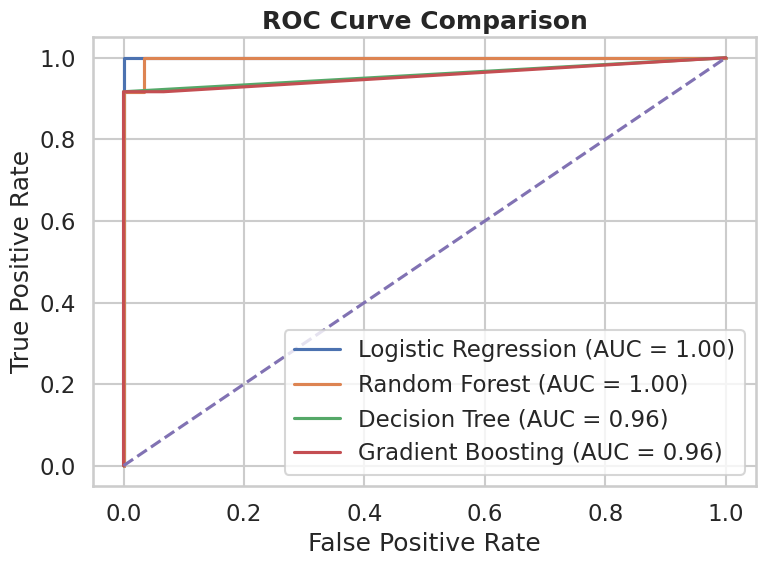

In [103]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_prob_lor = lor.predict_proba(X_test)[:,1]
y_prob_rfc = rfc.predict_proba(X_test)[:,1]
y_prob_dtc = dtc.predict_proba(X_test)[:,1]
y_prob_gbc = gbc.predict_proba(X_test)[:,1]

models_prob = {
    "Logistic Regression": y_prob_lor,
    "Random Forest": y_prob_rfc,
    "Decision Tree": y_prob_dtc,
    "Gradient Boosting": y_prob_gbc
}

plt.figure(figsize=(8,6))

for name, y_prob in models_prob.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# diagonal line (random model)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison", weight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("roc_all_models.png", dpi=300)
plt.show()